# Clustering con scikit-learn

Esempi semplici di **K-Means**, **DBSCAN** e **Agglomerative Clustering** su dati sintetici.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

np.random.seed(42)
print('Librerie caricate correttamente.')

Librerie caricate correttamente.


## 1. Dataset sintetici

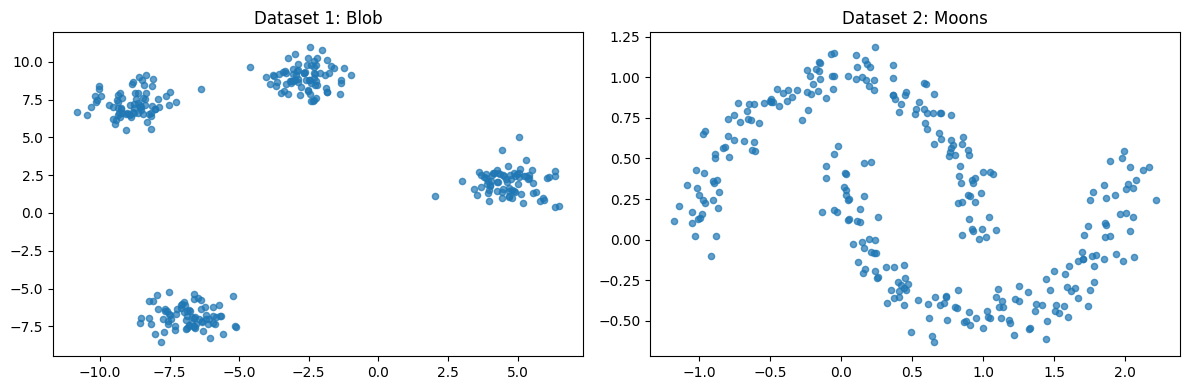

In [2]:
# Dataset 1: blob ben separati (ideale per K-Means)
X_blobs, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

# Dataset 2: forma a mezzaluna (difficile per K-Means, ottimo per DBSCAN)
X_moons, _ = make_moons(n_samples=300, noise=0.08, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], s=20, alpha=0.7)
axes[0].set_title('Dataset 1: Blob')
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], s=20, alpha=0.7)
axes[1].set_title('Dataset 2: Moons')
plt.tight_layout()
plt.show()

## 2. K-Means

Divide i dati in **k gruppi** minimizzando la distanza intra-cluster. Richiede di specificare k in anticipo.

` s = (b - a) / max(a, b) ` -> silhouette score: per ogni punto calcola coesione interna (dist media del punto da tutti gli altri nello stesso cluster) e separazione esterna (dist media tra il punto e tutti i punti del cluster più vicino)

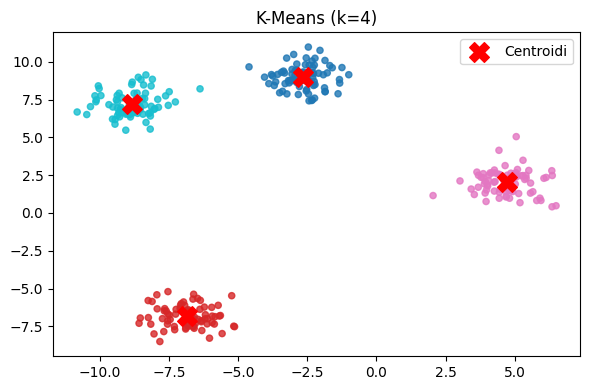

Silhouette Score: 0.834  (più vicino a 1 = meglio)


In [4]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels_km = kmeans.fit_predict(X_blobs)

plt.figure(figsize=(6, 4))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_km, cmap='tab10', s=20, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker='X', s=200, c='red', label='Centroidi')
plt.title('K-Means (k=4)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Silhouette Score: {silhouette_score(X_blobs, labels_km):.3f}  (più vicino a 1 = meglio)')

### Come scegliere k? — Metodo del gomito (Elbow)

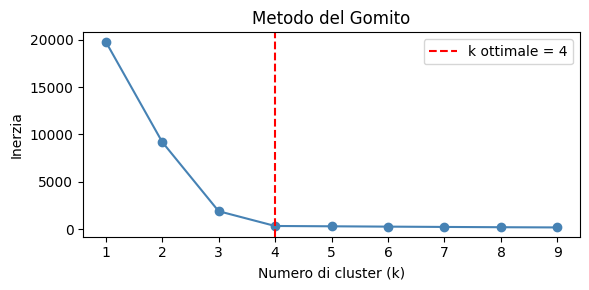

In [ ]:
inertie = [] #inertia è un attributo che rappresenta la somma delle distanze al quadrato di ogni punto dal suo centroide
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_blobs)
    inertie.append(km.inertia_)

plt.figure(figsize=(6, 3))
plt.plot(K_range, inertie, 'o-', color='steelblue')
plt.axvline(4, color='red', linestyle='--', label='k ottimale = 4')
plt.xlabel('Numero di cluster (k)')
plt.ylabel('Inerzia')
plt.title('Metodo del Gomito')
plt.legend()
plt.tight_layout()
plt.show()

## 3. DBSCAN

Trova cluster di **forma arbitraria** basandosi sulla densità. Non serve specificare k, ma identifica automaticamente i punti rumore (label = -1).

Si basa su due parametri:
- eps: raggio entro cui cercare i vicini
- min_samples: quanti vicini servono per formare un cluster

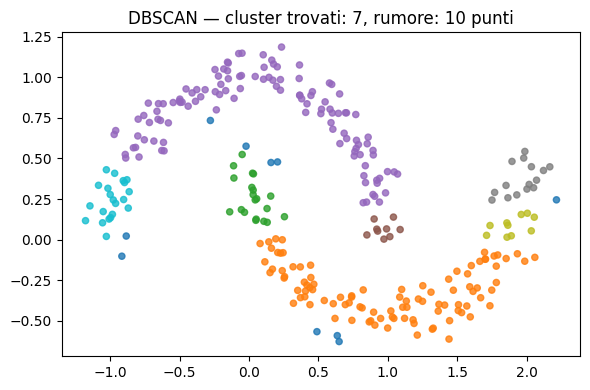

In [6]:
scaler = StandardScaler()
X_moons_scaled = scaler.fit_transform(X_moons)

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_db = dbscan.fit_predict(X_moons_scaled)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise    = (labels_db == -1).sum()

plt.figure(figsize=(6, 4))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_db, cmap='tab10', s=20, alpha=0.8)
plt.title(f'DBSCAN — cluster trovati: {n_clusters}, rumore: {n_noise} punti')
plt.tight_layout()
plt.show()

## 4. Agglomerative Clustering

Clustering **gerarchico**: unisce i punti dal basso verso l'alto. Utile quando non si conosce k ma si vuole esplorare la struttura dei dati.

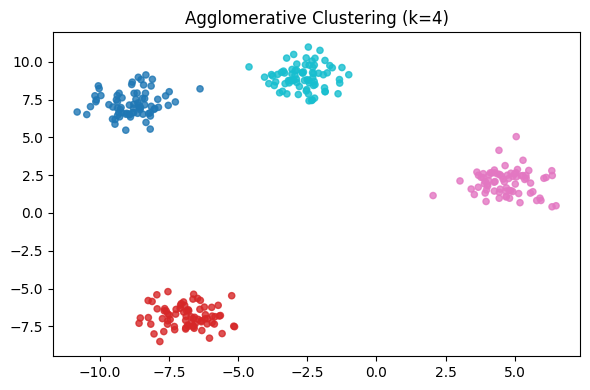

Silhouette Score: 0.834


In [7]:
agg = AgglomerativeClustering(n_clusters=4)
labels_agg = agg.fit_predict(X_blobs)

plt.figure(figsize=(6, 4))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_agg, cmap='tab10', s=20, alpha=0.8)
plt.title('Agglomerative Clustering (k=4)')
plt.tight_layout()
plt.show()

print(f'Silhouette Score: {silhouette_score(X_blobs, labels_agg):.3f}')

## 5. Confronto visivo dei tre algoritmi

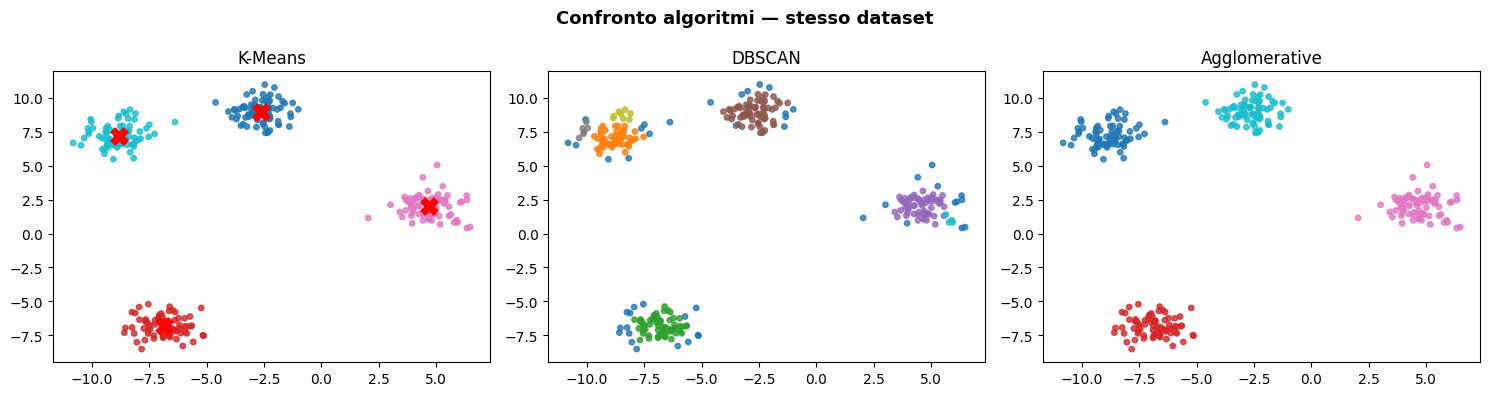

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# K-Means
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_km, cmap='tab10', s=15, alpha=0.8)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                marker='X', s=150, c='red')
axes[0].set_title('K-Means')

# DBSCAN (sui blob)
labels_db2 = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_blobs)
axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_db2, cmap='tab10', s=15, alpha=0.8)
axes[1].set_title('DBSCAN')

# Agglomerative
axes[2].scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_agg, cmap='tab10', s=15, alpha=0.8)
axes[2].set_title('Agglomerative')

plt.suptitle('Confronto algoritmi — stesso dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Riepilogo

| Algoritmo | Devi specificare k? | Gestisce forme strane? | Rileva outlier? |
|---|---|---|---|
| **K-Means** | Sì | No | No |
| **DBSCAN** | No | Sì | Sì |
| **Agglomerative** | Sì | Parzialmente | No |